In [31]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [32]:
df = pd.read_csv("RUN_dataset.csv")
X = df.drop(columns=["has_conflict"]).values
y = df["has_conflict"].values

In [33]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [34]:
total_samples = len(X_tensor)
indices = np.arange(total_samples)
np.random.shuffle(indices)

In [35]:
train_size = int(0.7 * total_samples)
valid_size = int(0.15 * total_samples)
test_size = total_samples - train_size - valid_size

In [36]:
train_indices = indices[:train_size]
valid_indices = indices[train_size: train_size + valid_size]
test_indices  = indices[train_size + valid_size:]

In [37]:
class ActiveDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], idx

In [38]:
train_active_dataset = ActiveDataset(X_tensor[train_indices], y_tensor[train_indices])
valid_dataset = TensorDataset(X_tensor[valid_indices], y_tensor[valid_indices])
test_dataset  = TensorDataset(X_tensor[test_indices], y_tensor[test_indices])

valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [39]:
class MergeConflictPredictor(nn.Module):
    def __init__(self, input_size):
        super(MergeConflictPredictor, self).__init__()
        self.fc1 = nn.Linear(input_size, 128*2)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128*2, 64*2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64*2, 32*2)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(32*2, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.sigmoid(self.fc4(x))
        return x

In [40]:
input_size = X.shape[1]  
model = MergeConflictPredictor(input_size).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.00005)

print(model)

MergeConflictPredictor(
  (fc1): Linear(in_features=41, out_features=256, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [41]:
def train_model_al(model, loader, criterion, optimizer, device, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_X, batch_y, _ in loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch_X.size(0)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader.dataset):.4f}")


In [42]:
def query_least_confidence(model, unlabeled_loader, query_size, device):
    model.eval()
    uncertainties = []
    indices = []
    with torch.no_grad():
        for data, label, idx in unlabeled_loader:
            data = data.to(device)
            outputs = model(data)
            probs = outputs.view(-1) 
            uncertainty = 1 - 2 * torch.abs(probs - 0.5) 
            uncertainties.extend(uncertainty.cpu().numpy())
            indices.extend(idx.numpy())
    uncertainties = np.array(uncertainties)
    indices = np.array(indices)
    query_indices = indices[np.argsort(-uncertainties)][:query_size]
    return query_indices.tolist()

In [43]:
def active_learning_loop(model, optimizer, criterion, dataset, valid_loader, test_loader,
                         initial_labeled=200, query_size=50, iterations=5, batch_size=32, device="cpu"):
    total = len(dataset)
    all_indices = list(range(total))
    np.random.shuffle(all_indices)
    
    labeled_indices = all_indices[:initial_labeled]
    unlabeled_indices = all_indices[initial_labeled:]
    
    for it in range(iterations):
        print(f"\n---Active Learning Iteration {it+1}/{iterations}---")
        print(f"used: {len(labeled_indices)} | unused: {len(unlabeled_indices)}")
        
        labeled_subset = torch.utils.data.Subset(dataset, labeled_indices)
        labeled_loader = DataLoader(labeled_subset, batch_size=batch_size, shuffle=True)
        
        train_model_al(model, labeled_loader, criterion, optimizer, device, epochs=10)
        
        model.eval()
        correct = 0
        total_samples = 0
        with torch.no_grad():
            for data, target in valid_loader:
                data, target = data.to(device), target.to(device)
                outputs = model(data)
                preds = (outputs > 0.5).float()
                total_samples += target.size(0)
                correct += (preds == target).sum().item()
        acc = 100 * correct / total_samples
        print(f"Test Accuracy: {acc:.2f}%")
        
        if len(unlabeled_indices) == 0:
            print("No more unlabeled samples.")
            break
        
        unlabeled_subset = torch.utils.data.Subset(dataset, unlabeled_indices)
        unlabeled_loader = DataLoader(unlabeled_subset, batch_size=batch_size, shuffle=False)
        new_query = query_least_confidence(model, unlabeled_loader, query_size, device)
        print(f"Queried {len(new_query)} new samples.")
        

        labeled_indices.extend(new_query)
        unlabeled_indices = [idx for idx in unlabeled_indices if idx not in new_query]

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

start_time = time.time()

active_learning_loop(model, optimizer, criterion, train_active_dataset,
                     valid_loader, test_loader,
                     initial_labeled=200, query_size=100, iterations=15,
                     batch_size=32, device=device)

end_time = time.time()
elapsed_time = end_time - start_time

print(f"Total training time: {elapsed_time:.2f} seconds")


---Active Learning Iteration 1/15---
used: 200 | unused: 5330
Epoch 1/10, Loss: 0.6991
Epoch 2/10, Loss: 0.6959
Epoch 3/10, Loss: 0.6929
Epoch 4/10, Loss: 0.6900
Epoch 5/10, Loss: 0.6872
Epoch 6/10, Loss: 0.6845
Epoch 7/10, Loss: 0.6816
Epoch 8/10, Loss: 0.6787
Epoch 9/10, Loss: 0.6758
Epoch 10/10, Loss: 0.6726
Test Accuracy: 60.59%
Queried 100 new samples.

---Active Learning Iteration 2/15---
used: 300 | unused: 5230
Epoch 1/10, Loss: 0.6746
Epoch 2/10, Loss: 0.6634
Epoch 3/10, Loss: 0.6509
Epoch 4/10, Loss: 0.6370
Epoch 5/10, Loss: 0.6224
Epoch 6/10, Loss: 0.6068
Epoch 7/10, Loss: 0.5898
Epoch 8/10, Loss: 0.5723
Epoch 9/10, Loss: 0.5532
Epoch 10/10, Loss: 0.5345
Test Accuracy: 71.73%
Queried 100 new samples.

---Active Learning Iteration 3/15---
used: 400 | unused: 5130
Epoch 1/10, Loss: 0.5580
Epoch 2/10, Loss: 0.5421
Epoch 3/10, Loss: 0.5260
Epoch 4/10, Loss: 0.5099
Epoch 5/10, Loss: 0.4940
Epoch 6/10, Loss: 0.4783
Epoch 7/10, Loss: 0.4622
Epoch 8/10, Loss: 0.4467
Epoch 9/10, Los

In [15]:
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            preds = (outputs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    print(f"\nFinal Evaluation on Test Set:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Conflict", "Conflict"],
                yticklabels=["No Conflict", "Conflict"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()



Final Evaluation on Test Set:
Accuracy: 0.8996
Precision: 0.8877
Recall: 0.9286
F1 Score: 0.9077


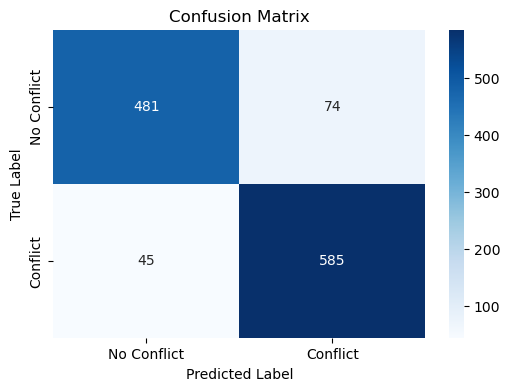

In [16]:
evaluate_model(model, test_loader, device)